# Task: Extract the mel-spectrogram from a watermarked audio sample using AudioSeal. Then, synthesize a waveform using HiFI-GAN based on the extracted mel-spectrogram. Finally, apply AudioSeal's watermark detector to determine weather the water persists on the generated audio.

install environment

In [1]:
!pip install librosa numpy soundfile torch

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


the process of mel-spectrogram extract

In [2]:
import librosa

def load_wav(path, sr=22050):
    """load audio from path"""
    wav, _ = librosa.load(path, sr=sr)
    return wav

def mel_spectrogram(wav, sr=22050, n_fft=1024, hop_length=256, win_length=1024,
                    n_mels=80, fmin=0, fmax=8000):
    """extract mel spectrogram from wav"""
    mel_spec = librosa.feature.melspectrogram(
        y=wav,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax,
        power=1.0
    )

    mel_spec = np.log(np.clip(mel_spec, a_min=1e-5, a_max=None))

    return mel_spec

In [3]:
import numpy as np

wav_path = "watermarked.wav"
output_path = "watermarked_mel.npy"

# extract
wav = load_wav(wav_path)
mel = mel_spectrogram(wav)

# save
np.save(output_path, mel)

In [4]:
import torch
hifigan, vocoder_train_setup, denoiser = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_hifigan')

Using cache found in C:\Users\wuann/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub
C:\Users\wuann/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub\PyTorch\Classification\ConvNets\image_classification\models\common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
C:\Users\wuann/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub\PyTorch\Classification\ConvNets\image_classification\models\efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
D:\programs\wm\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


HiFi-GAN: Removing weight norm.


In [5]:
import numpy as np

# 假设你加载了 mel.npy
mel = np.load("watermarked_mel.npy")            # shape: [80, T]
mel_tensor = torch.from_numpy(mel)  # 转换成 Tensor
mel_tensor = mel_tensor.unsqueeze(0)  # shape: [1, 80, T]
audios = hifigan(mel_tensor).float()


In [6]:
from notebook import play_audio, plot_waveform_and_specgram, plot_waveform_and_melspec
play_audio(audios, sample_rate=22050)

## import audioseal

In [7]:
%%capture

# For the demonstration, we need torchaudio and matplotlib to process example audios and visualize the spectrogram
import sys
!{sys.executable} -m pip install torchaudio soundfile matplotlib

In [8]:
from audioseal import AudioSeal

detector = AudioSeal.load_detector(("audioseal_detector_16bits"))

result, message = detector.detect_watermark(audios, sample_rate=22050, message_threshold=0.5)

print(f"\nThis is likely a watermarked audio: {result}")


This is likely a watermarked audio: 0.0


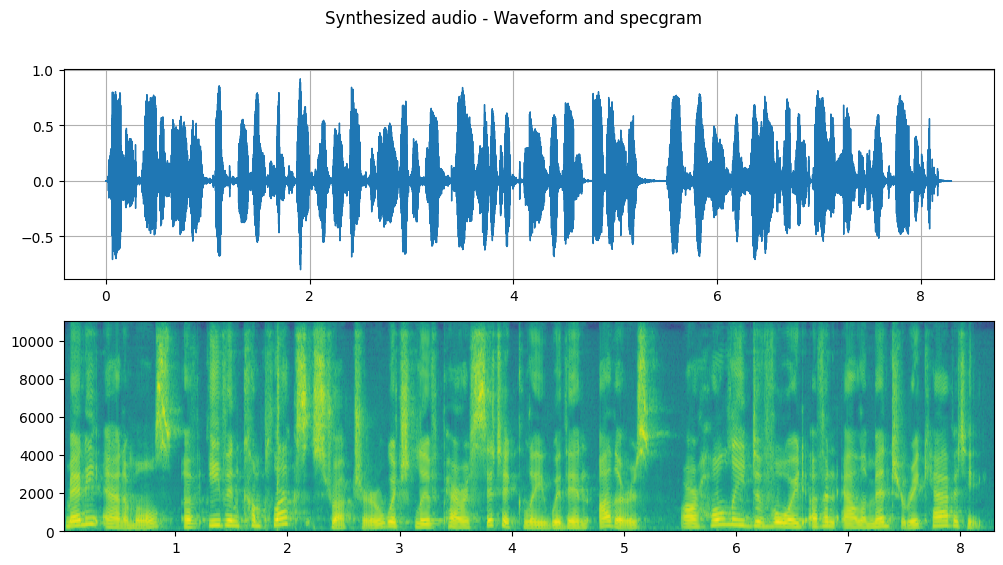

In [9]:
plot_waveform_and_specgram(audios, 22050, title="Synthesized audio")

In [10]:
import torchaudio
watermarked_audio, sr = torchaudio.load("watermarked.wav")

result, message = detector.detect_watermark(watermarked_audio.unsqueeze(0), sample_rate=22050, message_threshold=0.5)

print(f"\nThis is likely a watermarked audio: {result}")


This is likely a watermarked audio: 1.0


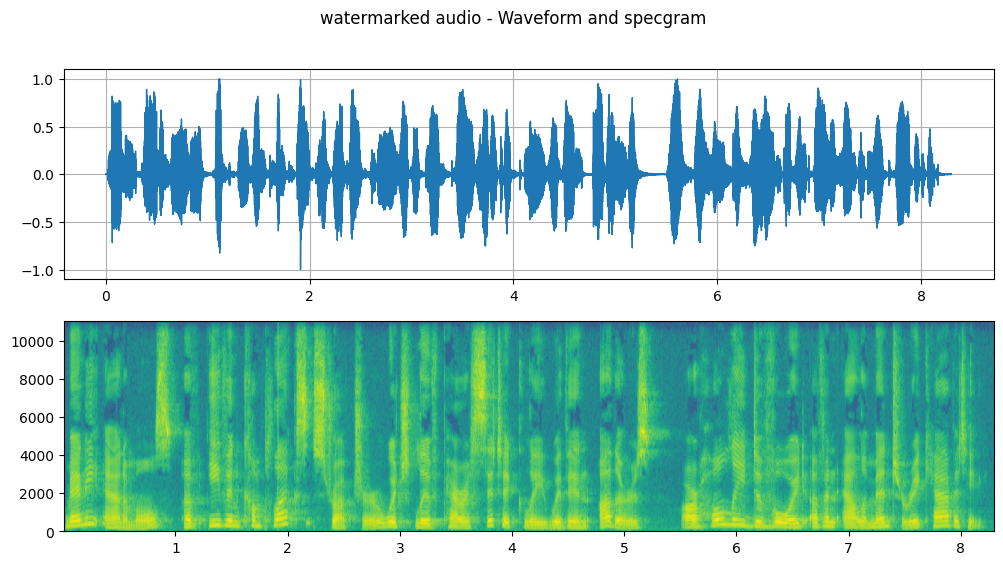

In [12]:
plot_waveform_and_specgram(watermarked_audio, 22050, title="watermarked audio")